In [1]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

c:\Users\super\anaconda3\envs\testetcc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
class BERTSentimentAnalyzer:
    def __init__(self, model_name="lipaoMai/bert-sentiment-model-portuguese"):
        """
        Inicializa o analisador de sentimento BERT para português
        """
        self.model_name = model_name
        self.tokenizer = None
        self.model = None
        self.classifier = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    def load_model(self):
        """
        Carrega o modelo BERT pré-treinado
        """
        print(f"Carregando modelo {self.model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(self.model_name)
        
        # Criar pipeline para facilitar a inferência
        self.classifier = pipeline(
            "sentiment-analysis",
            model=self.model,
            tokenizer=self.tokenizer,
            device=0 if torch.cuda.is_available() else -1,
            return_all_scores=True
        )
        print("Modelo carregado com sucesso!")
        
    def preprocess_text(self, text):
        """
        Pré-processamento básico do texto
        """
        if pd.isna(text):
            return ""
        
        text = str(text)
        # Remove quebras de linha e espaços extras
        text = text.replace('\n', ' ').replace('\r', ' ')
        text = ' '.join(text.split())
        
        # Trunca textos muito longos (BERT tem limite de 512 tokens)
        if len(text) > 500:
            text = text[:500]
            
        return text
    
    def predict_sentiment(self, text):
        """
        Prediz o sentimento de um texto individual
        """
        if not self.classifier:
            raise ValueError("Modelo não foi carregado. Execute load_model() primeiro.")
            
        text = self.preprocess_text(text)
        if not text:
            return None, 0.0
            
        try:
            results = self.classifier(text)
            # O modelo pode retornar diferentes labels, adaptamos conforme necessário
            # Assumindo que retorna POSITIVE/NEGATIVE ou similar
            sentiment_scores = {result['label']: result['score'] for result in results[0]}
            
            # Determina o sentimento predominante
            predicted_label = max(sentiment_scores, key=sentiment_scores.get)
            confidence = sentiment_scores[predicted_label]
            
            return predicted_label, confidence
            
        except Exception as e:
            print(f"Erro na predição: {e}")
            return None, 0.0
    
    def predict_batch(self, texts, batch_size=32):
        """
        Prediz sentimentos para uma lista de textos em lotes
        """
        results = []
        
        for i in tqdm(range(0, len(texts), batch_size), desc="Processando lotes"):
            batch_texts = texts[i:i+batch_size]
            batch_results = []
            
            for text in batch_texts:
                sentiment, confidence = self.predict_sentiment(text)
                batch_results.append({
                    'sentiment': sentiment,
                    'confidence': confidence
                })
            
            results.extend(batch_results)
            
        return results
    
    def analyze_ecommerce_reviews(self, df, text_column='review', rating_column=None):
        """
        Analisa avaliações de e-commerce
        
        Parameters:
        df: DataFrame com as avaliações
        text_column: nome da coluna com o texto das avaliações
        rating_column: nome da coluna com as notas (opcional, para comparação)
        """
        if text_column not in df.columns:
            raise ValueError(f"Coluna '{text_column}' não encontrada no DataFrame")
        
        print(f"Analisando {len(df)} avaliações...")
        
        # Realiza as predições
        texts = df[text_column].tolist()
        predictions = self.predict_batch(texts)
        
        # Adiciona resultados ao DataFrame
        df_results = df.copy()
        df_results['predicted_sentiment'] = [p['sentiment'] for p in predictions]
        df_results['sentiment_confidence'] = [p['confidence'] for p in predictions]
        
        # Mapeia sentimentos para scores numéricos para análise
        sentiment_mapping = {
            'POSITIVE': 1,
            'NEGATIVE': -1,
            'NEUTRAL': 0
        }
        
        df_results['sentiment_score'] = df_results['predicted_sentiment'].map(
            lambda x: sentiment_mapping.get(x, 0) if x else 0
        )
        
        # Se há coluna de rating, compara com as predições
        if rating_column and rating_column in df.columns:
            df_results = self.compare_with_ratings(df_results, rating_column)
        
        return df_results
    
    def compare_with_ratings(self, df, rating_column):
        """
        Compara sentimentos preditos com ratings numéricos
        """
        # Converte ratings para sentimentos esperados
        # Assumindo escala de 1-5: 1-2=NEGATIVE, 3=NEUTRAL, 4-5=POSITIVE
        def rating_to_sentiment(rating):
            if pd.isna(rating):
                return None
            if rating <= 2:
                return 'NEGATIVE'
            elif rating >= 4:
                return 'POSITIVE'
            else:
                return 'NEUTRAL'
        
        df['expected_sentiment'] = df[rating_column].apply(rating_to_sentiment)
        
        # Calcula métricas de comparação
        valid_comparisons = df.dropna(subset=['predicted_sentiment', 'expected_sentiment'])
        
        if len(valid_comparisons) > 0:
            accuracy = accuracy_score(
                valid_comparisons['expected_sentiment'],
                valid_comparisons['predicted_sentiment']
            )
            print(f"Precisão comparada com ratings: {accuracy:.3f}")
            
            # Relatório detalhado
            report = classification_report(
                valid_comparisons['expected_sentiment'],
                valid_comparisons['predicted_sentiment']
            )
            print("\nRelatório de Classificação:")
            print(report)
        
        return df
    
    def generate_insights(self, df):
        """
        Gera insights sobre os sentimentos das avaliações
        """
        insights = {}
        
        # Distribuição de sentimentos
        sentiment_dist = df['predicted_sentiment'].value_counts()
        insights['sentiment_distribution'] = sentiment_dist
        
        # Confiança média por sentimento
        confidence_by_sentiment = df.groupby('predicted_sentiment')['sentiment_confidence'].mean()
        insights['avg_confidence'] = confidence_by_sentiment
        
        # Estatísticas gerais
        insights['total_reviews'] = len(df)
        insights['avg_confidence_overall'] = df['sentiment_confidence'].mean()
        
        return insights
    
    def plot_results(self, df, insights):
        """
        Cria visualizações dos resultados
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Distribuição de sentimentos
        sentiment_counts = insights['sentiment_distribution']
        axes[0,0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%')
        axes[0,0].set_title('Distribuição de Sentimentos')
        
        # Confiança por sentimento
        conf_by_sent = insights['avg_confidence']
        axes[0,1].bar(conf_by_sent.index, conf_by_sent.values)
        axes[0,1].set_title('Confiança Média por Sentimento')
        axes[0,1].set_ylabel('Confiança')
        
        # Histograma de confiança
        axes[1,0].hist(df['sentiment_confidence'], bins=20, alpha=0.7)
        axes[1,0].set_title('Distribuição de Confiança')
        axes[1,0].set_xlabel('Confiança')
        axes[1,0].set_ylabel('Frequência')
        
        # Box plot de confiança por sentimento
        sentiments = df['predicted_sentiment'].unique()
        sentiment_data = [df[df['predicted_sentiment']==sent]['sentiment_confidence'].values 
                         for sent in sentiments]
        axes[1,1].boxplot(sentiment_data, labels=sentiments)
        axes[1,1].set_title('Confiança por Sentimento')
        axes[1,1].set_ylabel('Confiança')
        
        plt.tight_layout()
        plt.show()

In [10]:
# Exemplo de uso
def example_usage():
    """
    Exemplo de como usar o analisador com dados de e-commerce
    """
    # 1. Criar dados de exemplo (substitua pelo seu dataset real)
    sample_data = {
        'review': [
            'Produto excelente, superou minhas expectativas!',
            'Péssima qualidade, não recomendo.',
            'Produto ok, nada de especial.',
            'Adorei! Muito bom custo benefício.',
            'Chegou quebrado, muito decepcionante.',
            'Produto mediano, esperava mais pela marca.',
            'Fantástico! Voltarei a comprar.',
            'Não vale o preço que paguei.',
        ],
        'rating': [5, 1, 3, 4, 1, 3, 5, 2],
        'product': ['Smartphone', 'Fone', 'Notebook', 'Mouse', 'Teclado', 'Monitor', 'Tablet', 'Cabo']
    }
    
    df = pd.DataFrame(sample_data)
    
    # 2. Inicializar e carregar o modelo
    analyzer = BERTSentimentAnalyzer()
    analyzer.load_model()
    
    # 3. Analisar as avaliações
    results_df = analyzer.analyze_ecommerce_reviews(
        df, 
        text_column='review', 
        rating_column='rating'
    )
    
    # 4. Gerar insights
    insights = analyzer.generate_insights(results_df)
    
    # 5. Mostrar resultados
    print("\nResultados da Análise:")
    print(results_df[['review', 'rating', 'predicted_sentiment', 'sentiment_confidence']].head())
    
    print(f"\nInsights:")
    print(f"Total de avaliações: {insights['total_reviews']}")
    print(f"Confiança média: {insights['avg_confidence_overall']:.3f}")
    print(f"\nDistribuição de sentimentos:")
    print(insights['sentiment_distribution'])
    
    # 6. Plotar resultados
    analyzer.plot_results(results_df, insights)
    
    return results_df, insights

Carregando modelo lipaoMai/bert-sentiment-model-portuguese...


Device set to use cpu


Modelo carregado com sucesso!
Analisando 8 avaliações...


Processando lotes: 100%|██████████| 1/1 [00:00<00:00,  2.22it/s]


Precisão comparada com ratings: 0.250

Relatório de Classificação:
              precision    recall  f1-score   support

    NEGATIVE       0.00      0.00      0.00         3
     NEUTRAL       0.25      1.00      0.40         2
    POSITIVE       0.00      0.00      0.00         3

    accuracy                           0.25         8
   macro avg       0.08      0.33      0.13         8
weighted avg       0.06      0.25      0.10         8


Resultados da Análise:
                                            review  rating  \
0  Produto excelente, superou minhas expectativas!       5   
1                Péssima qualidade, não recomendo.       1   
2                    Produto ok, nada de especial.       3   
3               Adorei! Muito bom custo benefício.       4   
4            Chegou quebrado, muito decepcionante.       1   

  predicted_sentiment  sentiment_confidence  
0             NEUTRAL              0.876359  
1             NEUTRAL              0.917427  
2             NEU

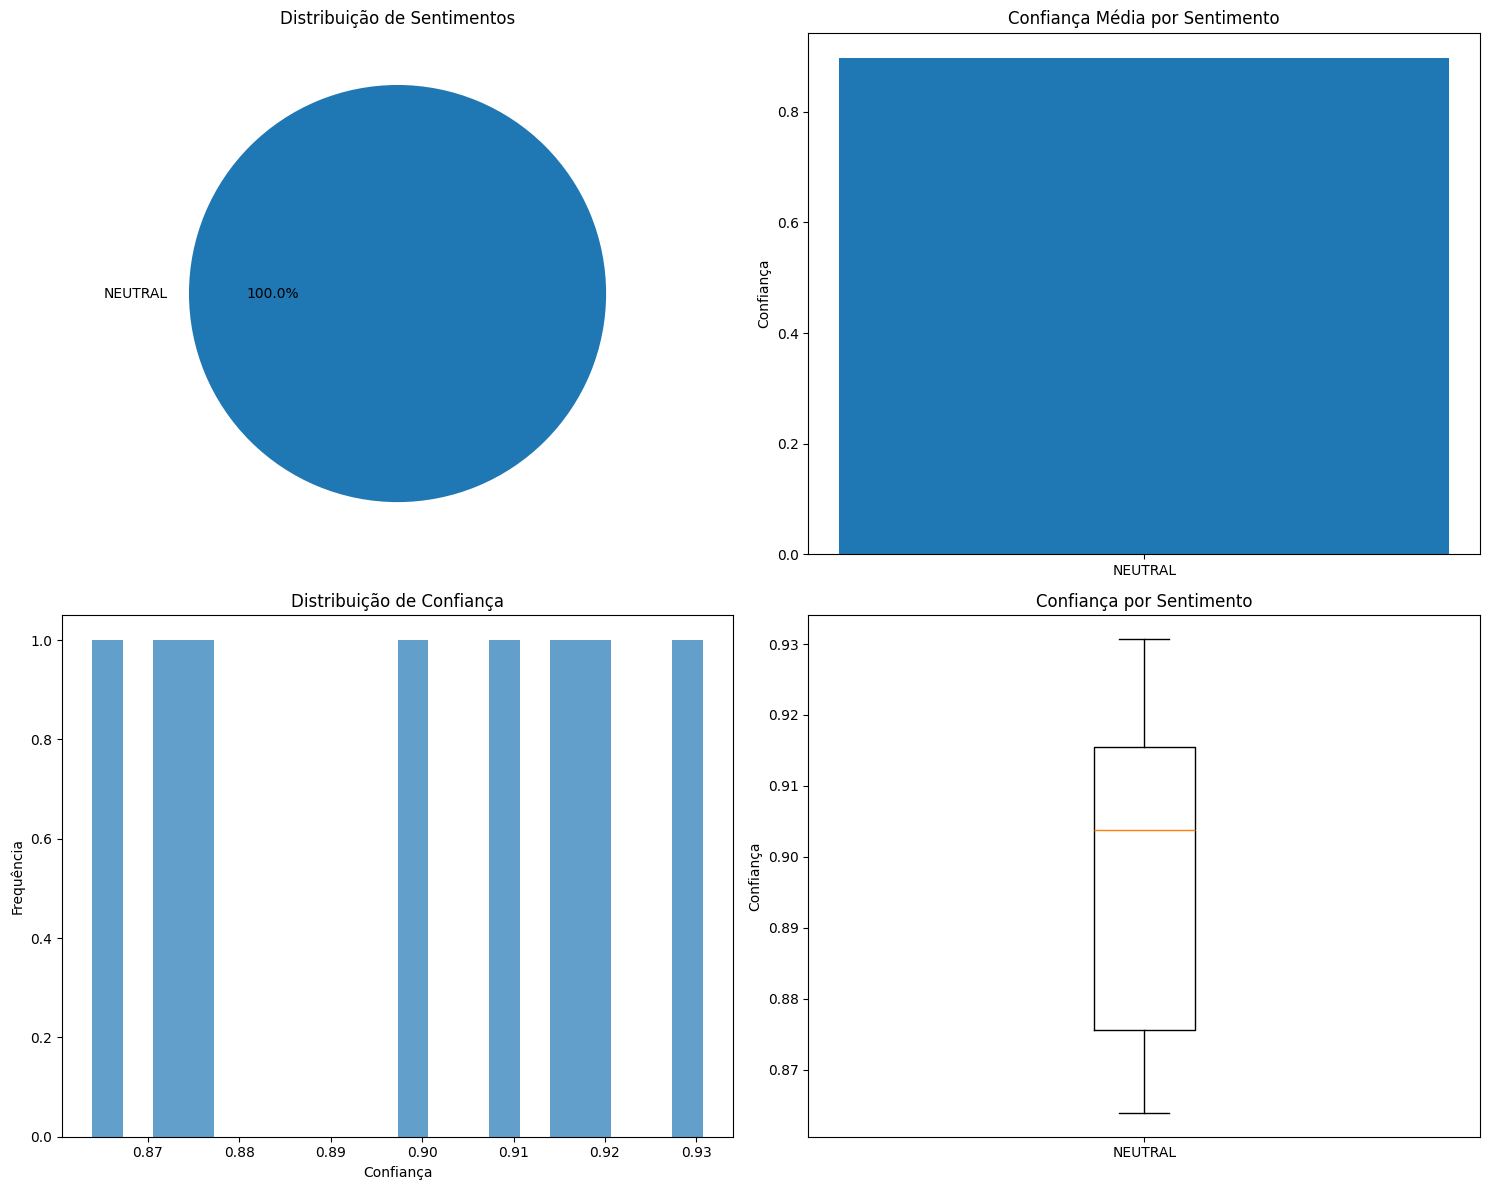

In [14]:
if __name__ == "__main__":
    # Executar exemplo
    results_df, insights = example_usage()

In [15]:
results_df.head(8)

,review,rating,product,predicted_sentiment,sentiment_confidence,sentiment_score,expected_sentiment
0,"Produto excelente, superou minhas expectativas!",5,Smartphone,NEUTRAL,0.876359,0,POSITIVE
1,"Péssima qualidade, não recomendo.",1,Fone,NEUTRAL,0.917427,0,NEGATIVE
2,"Produto ok, nada de especial.",3,Notebook,NEUTRAL,0.863912,0,NEUTRAL
3,Adorei! Muito bom custo benefício.,4,Mouse,NEUTRAL,0.897581,0,POSITIVE
4,"Chegou quebrado, muito decepcionante.",1,Teclado,NEUTRAL,0.914859,0,NEGATIVE
5,"Produto mediano, esperava mais pela marca.",3,Monitor,NEUTRAL,0.873430,0,NEUTRAL
6,Fantástico! Voltarei a comprar.,5,Tablet,NEUTRAL,0.930707,0,POSITIVE
7,Não vale o preço que paguei.,2,Cabo,NEUTRAL,0.910090,0,NEGATIVE
